In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter



url = 'https://drive.google.com/file/d/1iii4a4vTu-q9WU3KSHmpx3tYwZ1pJOT4/view?usp=drive_link'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]
products = pd.read_csv(path)

url = 'https://drive.google.com/file/d/1PNpDo9pGkWiZQKQ9JVi3VstWLbNuY1-E/view?usp=drive_link'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]
orders = pd.read_csv(path)

url = 'https://drive.google.com/file/d/1718GfbyGYVANnfEb6bL93kgYfiXhUs5S/view?usp=drive_link'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]
orderlines = pd.read_csv(path)

url = 'https://drive.google.com/file/d/1r_d9-hQflMgkQW4WSVCfqVojD0aVwU5h/view?usp=drive_link'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]
brands = pd.read_csv(path)

url = 'https://drive.google.com/file/d/1HQT-NmA3nltOKW91kLT6gXUQXxK71P4U/view?usp=drive_link'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]
merged = pd.read_csv(path)


In [2]:
df = merged.copy()
sales = df.copy()
sales['order_date_only'] = pd.to_datetime(sales['order_date_only'])

# **TOP 10 with Accessories**


,year,sku,name,product_quantity,common
59,2017,APP0698,Apple Lightning Cable Connector to USB 1m Whit...,320,False
71,2017,APP0927,EarPods Apple Headphones with Remote and Mic (...,191,False
369,2017,BEL0198,Belkin Rockstar Road 4 USB Car Charger 7.2A Black,182,False
121,2017,APP1190,IPhone AppleCare Protection Plan,129,True
748,2017,JAW0048,Jawbone UP2 Black Rope Activity Monitor,113,False
760,2017,JBL0122,JBL T450 BT Bluetooth Headset Black,87,False
1887,2017,WAC0171,Education - Wacom Intuos graphics tablet with ...,77,False
1896,2017,WDT0141,"WD Red 3TB 35 ""Mac PC hard drive and NAS",77,False
63,2017,APP0702,60W MagSafe charger Apple MacBook and MacBook ...,70,False
58,2017,APP0697,OEM USB Cable for iPhone iPad Dock and Apple i...,66,False


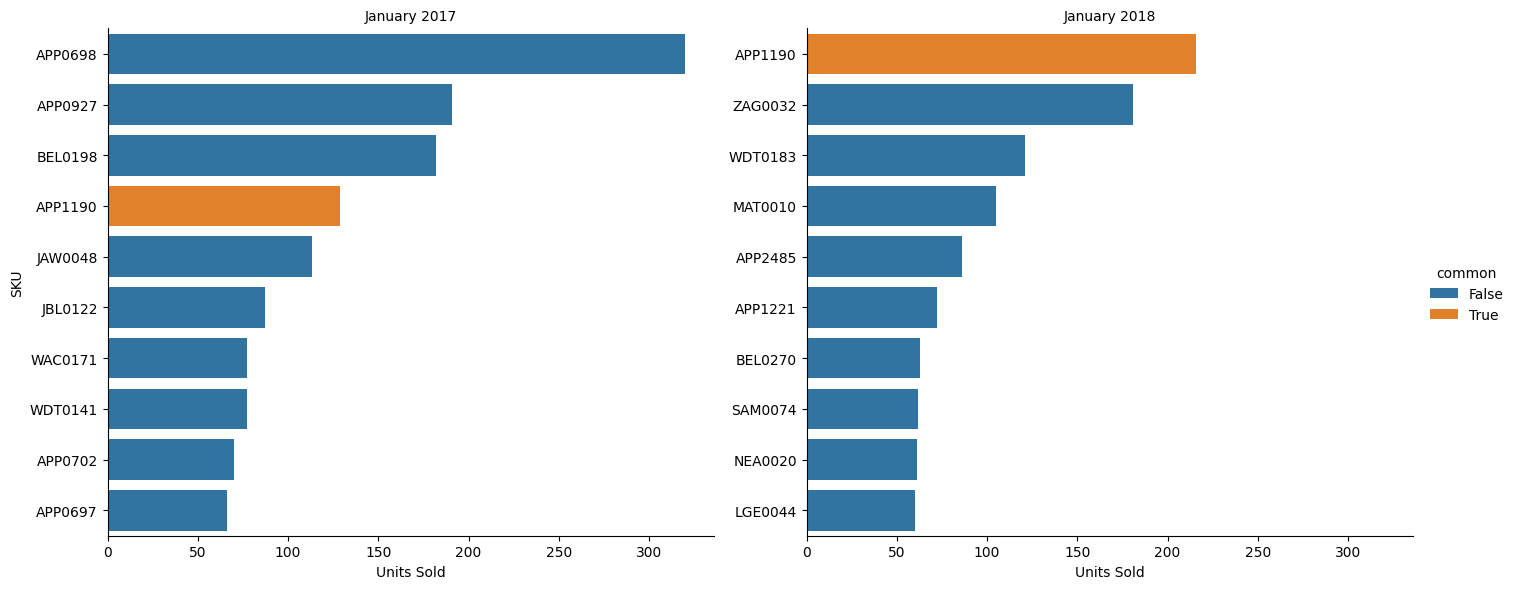

In [3]:
# Top 10 Products Jan 2017 vs Jan 2018

# Keep only sales that occurred in January
jan_sales = sales[sales['order_date_only'].dt.month == 1]

# Calculate total quantity sold for each product in January 2017 and January 2018
top10 = (
    jan_sales[jan_sales['order_date_only'].dt.year.isin([2017, 2018])]
    .groupby([jan_sales['order_date_only'].dt.year.rename('year'), 'sku', 'name'])['product_quantity']
    .sum()
    .reset_index()
)

# Sort products by quantity sold within each year and keep only the top 10 products per year
top10 = (
    top10
    .sort_values(['year', 'product_quantity'], ascending=[True, False])
    .groupby('year')
    .head(10)
)

# Find products that appear in the top 10 of both years using set
common = (
    set(top10[top10['year'] == 2017]['sku']) &
    set(top10[top10['year'] == 2018]['sku'])
)

# Created a True/False column indicating whether a product is in the top 10 of both years
top10['common'] = top10['sku'].isin(common)

# Created Barchart plot
catplot = sns.catplot(
    data=top10,
    kind='bar',
    x='product_quantity',
    y='sku',
    hue='common',
    col='year',
    height=6,
    aspect=1.2,
    sharey=False # each plot shows only its own top 10 SKUs
)

# Label the axes
catplot.set_axis_labels("Units Sold", "SKU")

# Set a title for each subplot
catplot.set_titles("January {col_name}")

# Show top 10
top10

# **TOP 10 without Accessories**

,year,sku,name,product_quantity,common
14,2017,APP0927,EarPods Apple Headphones with Remote and Mic (...,191,False
34,2017,APP1190,IPhone AppleCare Protection Plan,129,True
323,2017,JBL0122,JBL T450 BT Bluetooth Headset Black,87,False
873,2017,WAC0171,Education - Wacom Intuos graphics tablet with ...,77,False
881,2017,WDT0141,"WD Red 3TB 35 ""Mac PC hard drive and NAS",77,True
884,2017,WDT0183,"Red 4TB WD 35 ""Mac PC hard drive and NAS",57,True
231,2017,CRU0026-2,Crucial memory Mac 16GB (2x8GB) SO-DIMM DDR3 1...,53,False
127,2017,APP1735,Apple Watch 42mm Aluminum Case Series 2 Space ...,47,False
748,2017,SAN0099,SanDisk Connect Wireless Flash Drive 64GB Wire...,47,False
233,2017,CRU0032,Crucial Mac Memory 8GB DDR3 1333MHz SO-DIMM,41,False


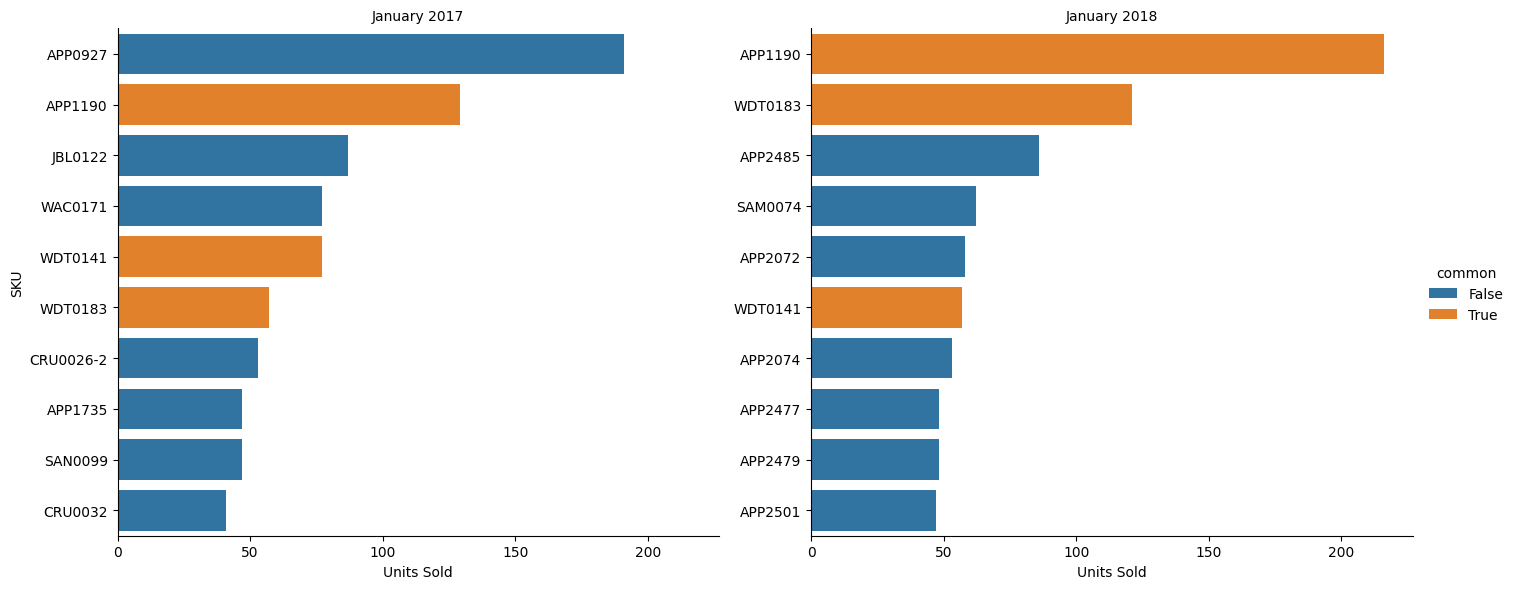

In [4]:
# Sales without Accessories

sales_without_accessories = sales.copy()

# Remove Accessories
sales_without_accessories = sales[
    sales['category'] != 'Accessories'
]

# Keep only January sales
jan_sales = sales_without_accessories[
    sales_without_accessories['order_date_only'].dt.month == 1
]

# Calculate total quantity sold for each product in January 2017 and January 2018
top10 = (
    jan_sales[jan_sales['order_date_only'].dt.year.isin([2017, 2018])]
    .groupby([jan_sales['order_date_only'].dt.year.rename('year'), 'sku', 'name'])['product_quantity']
    .sum()
    .reset_index()
)

# Sort products by quantity sold within each year and keep only the top 10 products per year
top10 = (
    top10
    .sort_values(['year', 'product_quantity'], ascending=[True, False])
    .groupby('year')
    .head(10)
)

# Find products that appear in the top 10 of both years using set
common = (
    set(top10[top10['year'] == 2017]['sku']) &
    set(top10[top10['year'] == 2018]['sku'])
)

# Created a True/False column indicating whether a product is in the top 10 of both years
top10['common'] = top10['sku'].isin(common)

# Created Barchart plot
catplot = sns.catplot(
    data=top10,
    kind='bar',
    x='product_quantity',
    y='sku',
    hue='common',
    col='year',
    height=6,
    aspect=1.2,
    sharey=False # each plot shows only its own top 10 SKUs
)

# Label the axes
catplot.set_axis_labels("Units Sold", "SKU")

# Set a title for each subplot
catplot.set_titles("January {col_name}")

# Show top 10
top10

In [5]:
df_without_spike = sales[
    ~(
        (sales['order_date_only'] >= '2017-11-20') &
        (sales['order_date_only'] <= '2018-02-01')
    )
]

df_spike = sales[
    (
        (sales['order_date_only'] >= '2017-11-20') &
        (sales['order_date_only'] <= '2018-02-01')
    )
]


In [6]:
discounted_orders_no_spike = df_without_spike[df_without_spike['discount'] > 0]
not_discounted_orders_no_spike = df_without_spike[df_without_spike['discount'] >= 0]

#**Performance During Christmas & Black Friday vs Other Periods**

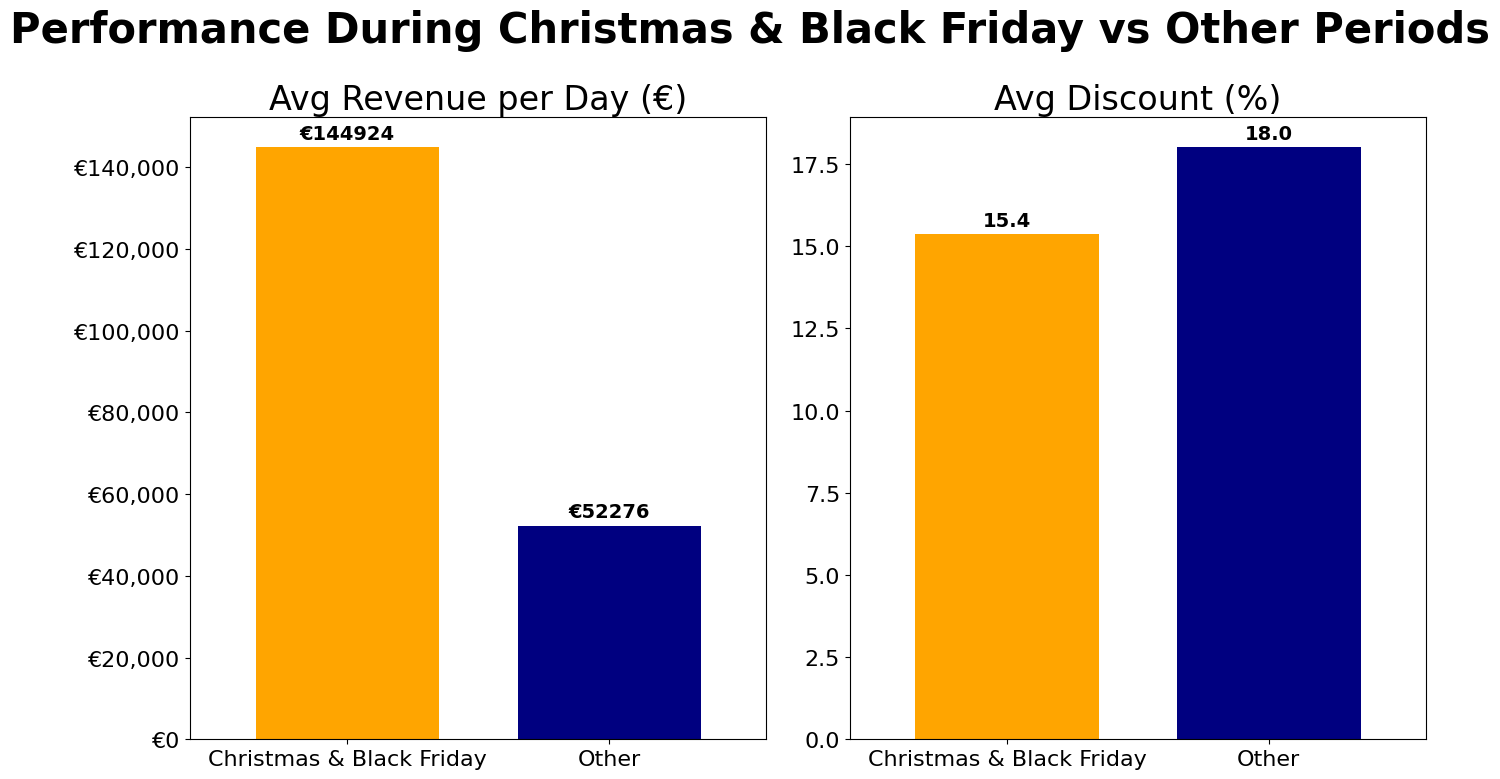

In [7]:


sales['period'] = 'Other'

sales.loc[
    (sales['order_date_only'] >= '2017-11-20') &
    (sales['order_date_only'] <= '2018-02-01'),
    'period'
] = 'Christmas & Black Friday'

period_summary = sales.groupby('period').agg(
    revenue=('unit_price_total', 'sum'),
    orders=('order_id', 'nunique'),
    avg_discount=('order_discount_percentage(%)', 'mean'),
    days=('order_date_only', lambda x: x.dt.date.nunique())
)

period_summary['revenue_per_day'] = (
    period_summary['revenue'] / period_summary['days']
)

period_summary['orders_per_day'] = (
    period_summary['orders'] / period_summary['days']
)

period_summary

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 24,
    'axes.labelsize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16
})

from matplotlib.ticker import FuncFormatter

metrics = [
    'revenue_per_day',
    'avg_discount'
]

titles = [
    'Avg Revenue per Day (€)',
    'Avg Discount (%)'
]

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for ax, metric, title in zip(axes, metrics, titles):

    colors = [
        'orange' if period == 'Christmas & Black Friday' else 'navy'
        for period in period_summary.index
    ]

    period_summary[metric].plot(
        kind='bar',
        ax=ax,
        color=colors,
        width=0.7
    )

    # Title
    ax.set_title(title, fontsize=24)

    # Axis labels and ticks
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0, labelsize=16)
    ax.tick_params(axis='y', labelsize=16)

    # Revenue axis in €
    if metric == 'revenue_per_day':
        ax.yaxis.set_major_formatter(
            FuncFormatter(lambda x, pos: f'€{x:,.0f}')
        )

    # Value labels on bars
    for container in ax.containers:
        ax.bar_label(
            container,
            fontsize=14,
            fontweight='bold',
            padding=3,
            fmt='€%.0f' if metric == 'revenue_per_day' else '%.1f'
        )

plt.suptitle(
    'Performance During Christmas & Black Friday vs Other Periods',
    fontsize=30,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

#**Revenue by discount bins**

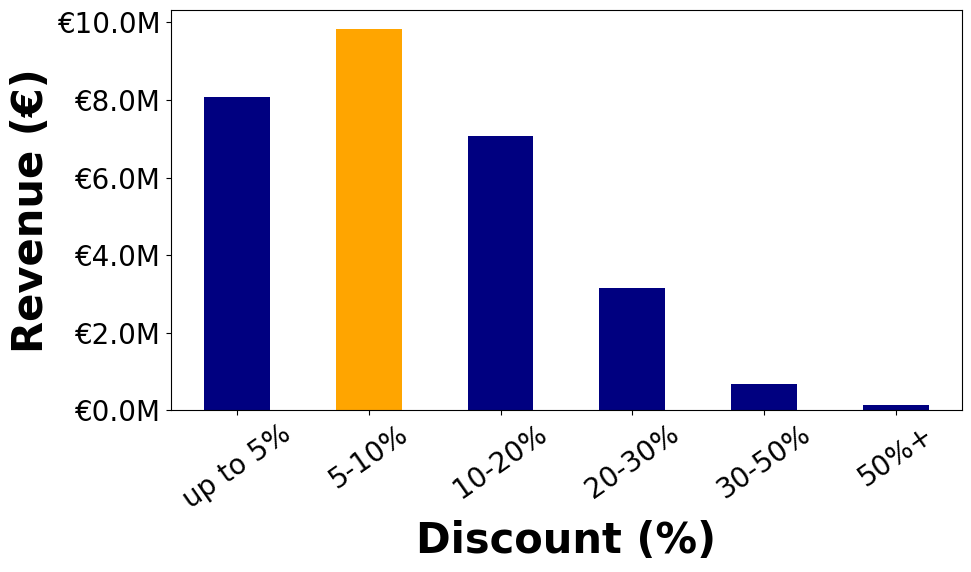

In [8]:
#Revenue by discount
sales['discount_band'] = pd.cut(
    sales['order_discount_percentage(%)'],
    bins=[0, 5, 10, 20, 30, 50, 100],
    labels=[
        'up to 5%',
        '5-10%',
        '10-20%',
        '20-30%',
        '30-50%',
        '50%+'
    ]
)

revenue_by_discount = (
    sales.groupby('discount_band', observed=True)['unit_price_total']
    .sum()
)

max_idx = revenue_by_discount.idxmax()

colors = [
    'orange' if idx == max_idx else 'navy'
    for idx in revenue_by_discount.index
]

fig, ax = plt.subplots(figsize=(10, 6))

revenue_by_discount.plot(
    kind='bar',
    color=colors,
    ax=ax
)

# Format y-axis as € millions
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'€{x/1e6:.1f}M')
)

ax.set_xlabel('Discount (%)', fontsize=30, fontweight='bold')
ax.set_ylabel('Revenue (€)', fontsize=30, fontweight='bold')

ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)

plt.xticks(rotation=35)

plt.tight_layout()
plt.show()

# **Revenue by Categories**

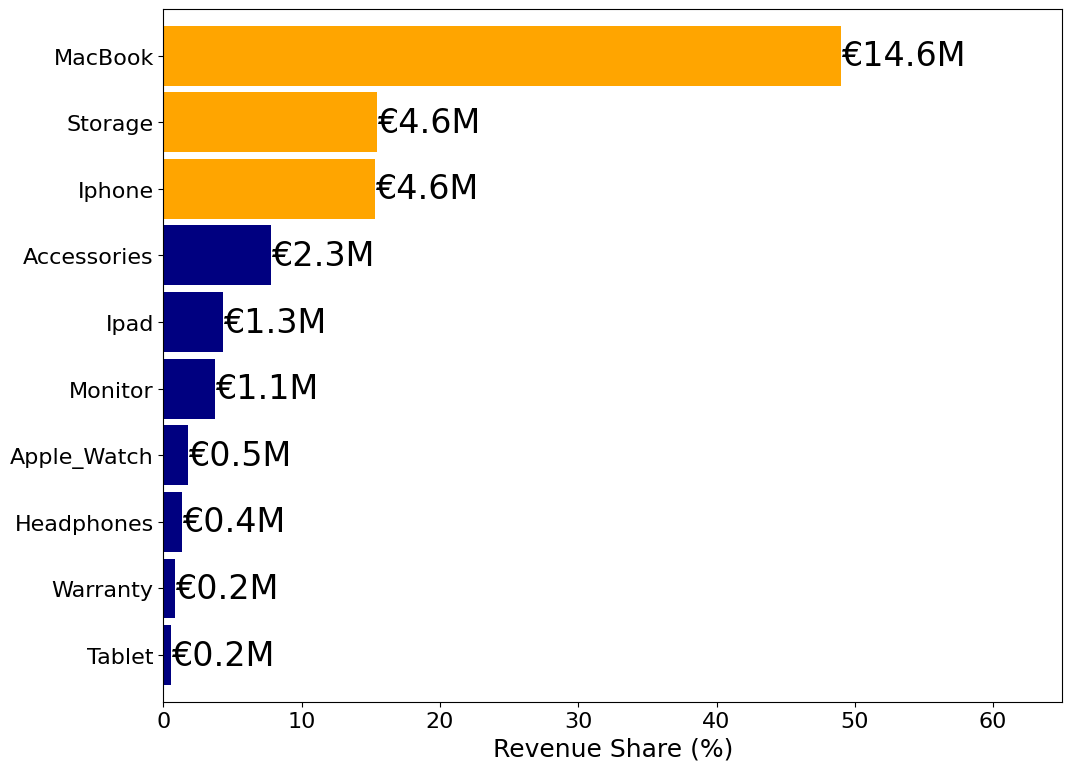

In [9]:
category_summary = sales.groupby('category').agg( revenue=('unit_price_total', 'sum'), avg_discount=('order_discount_percentage(%)', 'mean'), products=('sku', 'nunique') ).sort_values('revenue', ascending=False)
category_summary['revenue_share'] = ( category_summary['revenue'] / category_summary['revenue'].sum() * 100 )

plot_data = category_summary.sort_values( 'revenue_share', ascending=True )

top3 = category_summary.nlargest(3, 'revenue_share').index
colors = [ 'orange' if cat in top3 else 'navy' for cat in plot_data.index ]

fig, ax = plt.subplots(figsize=(11, 8))

plot_data['revenue_share'].plot(
    kind='barh',
    color=colors,
    ax=ax,
    width=0.9
)

for i, (share, revenue) in enumerate(
    zip(plot_data['revenue_share'], plot_data['revenue'])
):
    ax.text(
        share,
        i,
        f'€{revenue/1e6:.1f}M',
        va='center',
        fontsize=24,
    )


ax.set_xlabel('Revenue Share (%)')
ax.set_ylabel('')

ax.set_xlim(0, plot_data['revenue_share'].max() + 16)

plt.tight_layout()
plt.show()